In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import joblib 
import warnings 
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE


In [4]:
df = pd.read_csv('churn_dataset.csv')

df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

In [5]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
#check if data is balanced, by using "Exited" in the CSV file 

df['Exited'].value_counts()
print(f"Class Imbalance Ratio: {df['Exited'].value_counts()[0] / df['Exited'].value_counts()[1]:.2f}:1")

Class Imbalance Ratio: 3.91:1


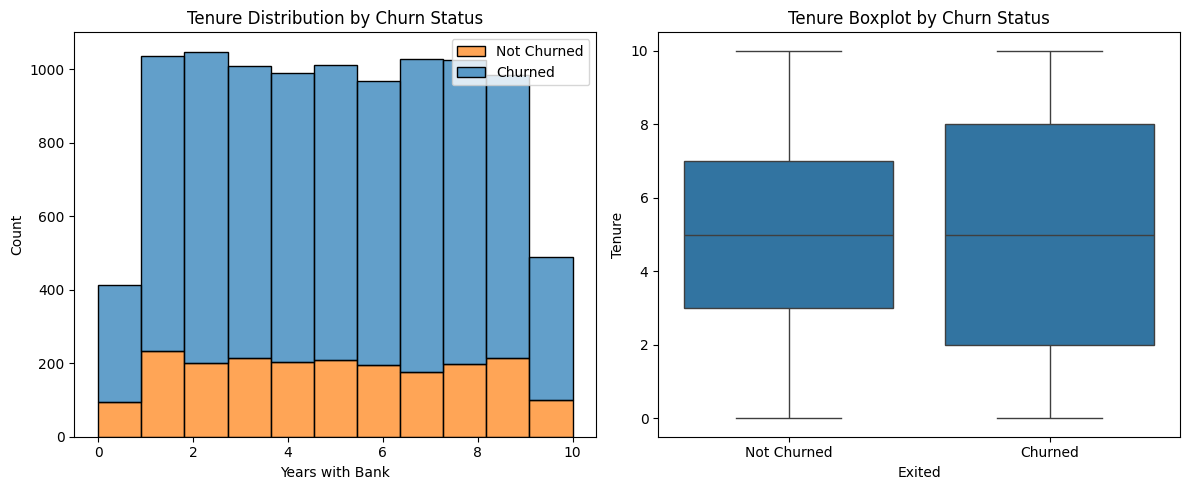

Tenure Statistics:
Mean Tenure - Not Churned: 5.0 years
Mean Tenure - Churned: 4.9 years
Tenure Correlation with Churn: -0.014


In [7]:
# Tenure analysis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Tenure', hue='Exited', multiple='stack', bins=11, alpha=0.7)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Years with Bank')
plt.legend(['Not Churned', 'Churned'])

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Exited', y='Tenure')
plt.title('Tenure Boxplot by Churn Status')
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.tight_layout()
plt.show()

# Statistics
print("Tenure Statistics:")
print(f"Mean Tenure - Not Churned: {df[df['Exited']==0]['Tenure'].mean():.1f} years")
print(f"Mean Tenure - Churned: {df[df['Exited']==1]['Tenure'].mean():.1f} years")
print(f"Tenure Correlation with Churn: {df['Tenure'].corr(df['Exited']):.3f}")

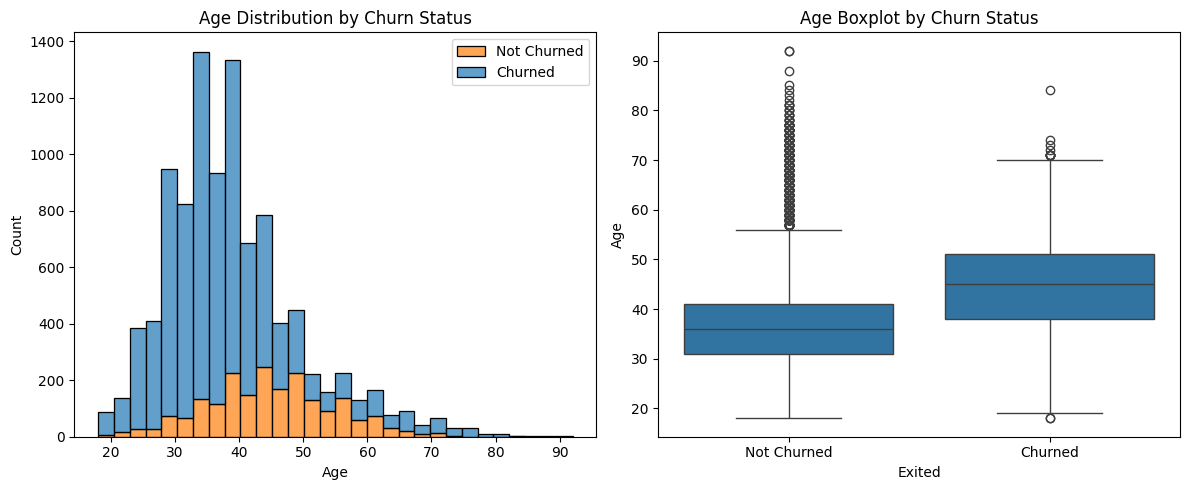

Age Statistics:
Mean Age - Not Churned: 37.4 years
Mean Age - Churned: 44.8 years
Age Correlation with Churn: 0.285


In [8]:
# Age analysis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', hue='Exited', multiple='stack', bins=30, alpha=0.7)
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.legend(['Not Churned', 'Churned'])

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Exited', y='Age')
plt.title('Age Boxplot by Churn Status')
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.tight_layout()
plt.show()

# Statistics
print("Age Statistics:")
print(f"Mean Age - Not Churned: {df[df['Exited']==0]['Age'].mean():.1f} years")
print(f"Mean Age - Churned: {df[df['Exited']==1]['Age'].mean():.1f} years")
print(f"Age Correlation with Churn: {df['Age'].corr(df['Exited']):.3f}")

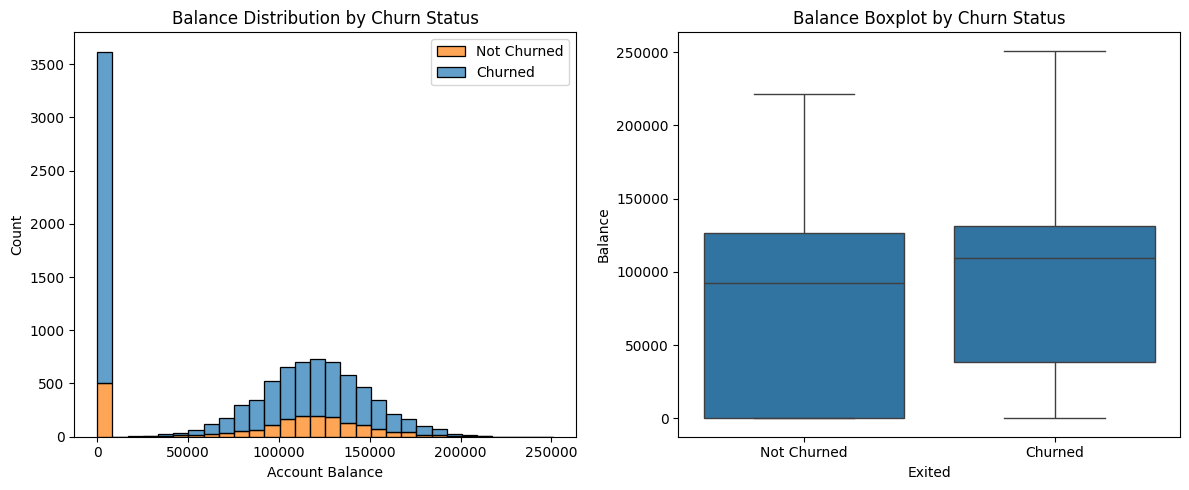

Balance Statistics:
Mean Balance - Not Churned: $72,745
Mean Balance - Churned: $91,109
Balance Correlation with Churn: 0.119


In [9]:
# Balance analysis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Balance', hue='Exited', multiple='stack', bins=30, alpha=0.7)
plt.title('Balance Distribution by Churn Status')
plt.xlabel('Account Balance')
plt.legend(['Not Churned', 'Churned'])

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Exited', y='Balance')
plt.title('Balance Boxplot by Churn Status')
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.tight_layout()
plt.show()

# Statistics
print("Balance Statistics:")
print(f"Mean Balance - Not Churned: ${df[df['Exited']==0]['Balance'].mean():,.0f}")
print(f"Mean Balance - Churned: ${df[df['Exited']==1]['Balance'].mean():,.0f}")
print(f"Balance Correlation with Churn: {df['Balance'].corr(df['Exited']):.3f}")

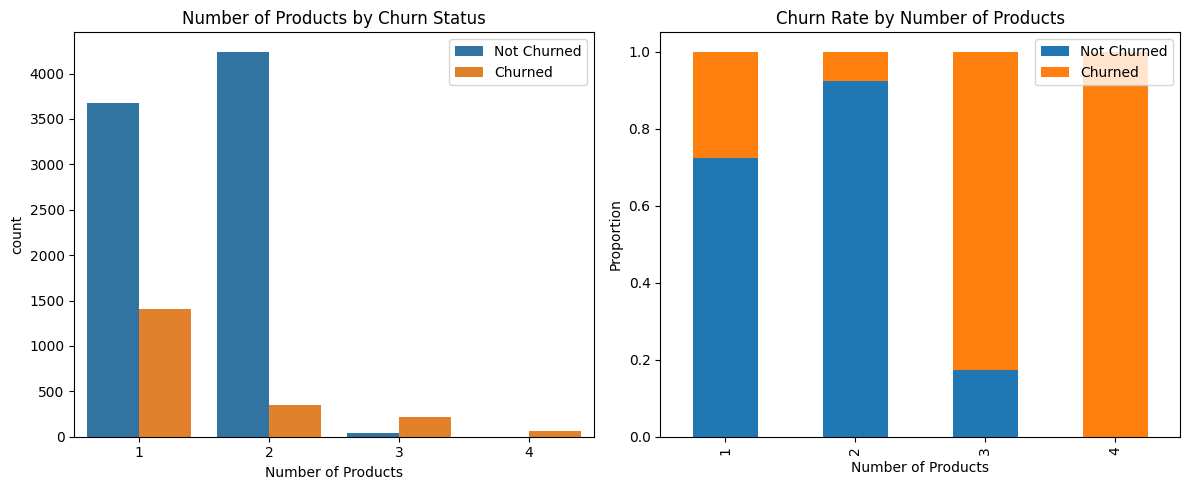

NumOfProducts Statistics:
Churn Rate by Number of Products:
1 products: 27.7%
2 products: 7.6%
3 products: 82.7%
4 products: 100.0%
NumOfProducts Correlation with Churn: -0.048


In [10]:
# NumOfProducts analysis
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='NumOfProducts', hue='Exited')
plt.title('Number of Products by Churn Status')
plt.xlabel('Number of Products')
plt.legend(['Not Churned', 'Churned'])

plt.subplot(1, 2, 2)
products_churn = pd.crosstab(df['NumOfProducts'], df['Exited'], normalize='index')
products_churn.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Proportion')
plt.legend(['Not Churned', 'Churned'])
plt.tight_layout()
plt.show()

# Statistics
print("NumOfProducts Statistics:")
products_churn_rate = pd.crosstab(df['NumOfProducts'], df['Exited'], normalize='index')[1]
print("Churn Rate by Number of Products:")
for products, rate in products_churn_rate.items():
    print(f"{products} products: {rate:.1%}")
print(f"NumOfProducts Correlation with Churn: {df['NumOfProducts'].corr(df['Exited']):.3f}")

In [11]:
#Encode Binary Columns 

categorical_cols = ['Geography', 'Gender']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

joblib.dump(encoders, 'encoders.joblib')

['encoders.joblib']

In [12]:
X = df.drop('Exited', axis = 1)
Y = df['Exited']

x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, stratify=Y, random_state=42)

x_train.shape[0]

8000

In [13]:
x_test.shape[0]

2000

In [14]:
#fix imbalancing with smote 

smote = SMOTE(random_state=42)

x_train_balanced, y_train_balanced = smote.fit_resample(x_train, y_train)

#before smote
dict(y_train.value_counts())

{0: np.int64(6370), 1: np.int64(1630)}

In [15]:
#after smote 
dict(pd.Series(y_train_balanced).value_counts())

{1: np.int64(6370), 0: np.int64(6370)}

In [16]:
#train XGBoost Model 

xgb_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)

xgb_model.fit(x_train_balanced, y_train_balanced)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [17]:
y_train_pred = xgb_model.predict(x_train)
y_test_pred = xgb_model.predict(x_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)


In [18]:
print('Training Accuracy', train_acc)
print('Test Accuracy', test_acc)

Training Accuracy 0.847625
Test Accuracy 0.811


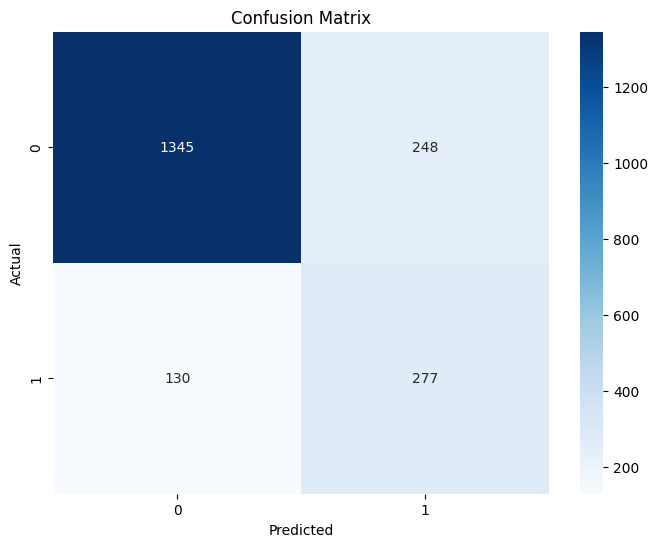

In [19]:
#Confusion Matrix to analyze model predictions 

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

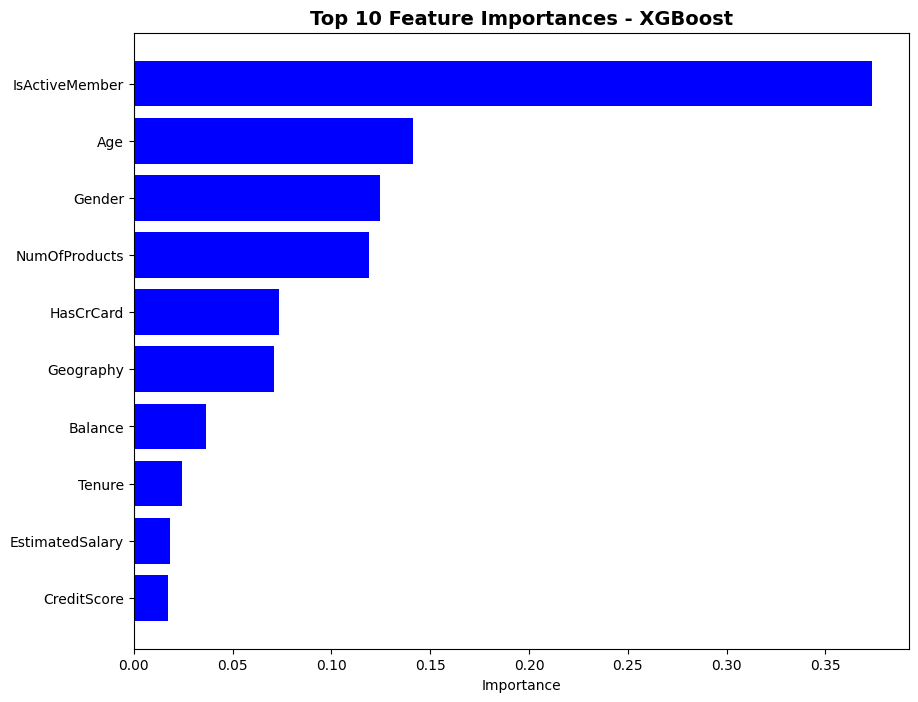

In [20]:
feature_importance = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance.head(10)

plt.figure(figsize=(10, 8))

plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10], color='blue')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances - XGBoost', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

In [21]:
#save model using joblib 

joblib.dump(xgb_model, 'customer_churn_model.pkl')

['customer_churn_model.pkl']